# Models

1. Ridge Regression (linear baseline)
2. Random Forest (non-linear)
3. LightGBM (gradient boosting)
4. XGBoost (gradient boosting)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

## 1. Load Processed Data

In [2]:
train = pd.read_csv('../data/processed/train_final.csv')
test = pd.read_csv('../data/processed/test_final.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (20804, 31)
Test shape: (4750, 30)


## 2. Prepare Features and Target

Separating features (X) and target (y), and applying log transformation to price.

In [3]:
# Columns to exclude from features
exclude_cols = ['id', 'host_id', 'price']

# Features and target
X = train.drop(columns=exclude_cols)
y = train['price']

# Apply log transformation to target (reduce skewness)
y_log = np.log1p(y)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nOriginal price - Skewness: {y.skew():.2f}")
print(f"Log price - Skewness: {y_log.skew():.2f}")

Features shape: (20804, 28)
Target shape: (20804,)

Original price - Skewness: 78.66
Log price - Skewness: 0.65


In [4]:
# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")

X_train: (16643, 28)
X_val: (4161, 28)


In [5]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## 3. Model Training & Evaluation

### 3.1 Ridge Regression (Linear Baseline)

In [6]:
# Train Ridge Regression
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Predict
y_pred_ridge = ridge.predict(X_val_scaled)

# Convert back from log scale
y_pred_ridge_original = np.expm1(y_pred_ridge)
y_val_original = np.expm1(y_val)

# Evaluate
rmse_ridge = np.sqrt(mean_squared_error(y_val_original, y_pred_ridge_original))
mae_ridge = mean_absolute_error(y_val_original, y_pred_ridge_original)
r2_ridge = r2_score(y_val_original, y_pred_ridge_original)

print("Ridge Regression Results:")
print(f"RMSE: {rmse_ridge:,.2f} TL")
print(f"MAE: {mae_ridge:,.2f} TL")
print(f"R² Score: {r2_ridge:.4f}")

Ridge Regression Results:
RMSE: 15,894.69 TL
MAE: 2,288.63 TL
R² Score: 0.0130


### 3.2 Random Forest (Non-linear)

In [7]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # No scaling needed for tree models

# Predict
y_pred_rf = rf.predict(X_val)

# Convert back from log scale
y_pred_rf_original = np.expm1(y_pred_rf)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_val_original, y_pred_rf_original))
mae_rf = mean_absolute_error(y_val_original, y_pred_rf_original)
r2_rf = r2_score(y_val_original, y_pred_rf_original)

print("Random Forest Results:")
print(f"RMSE: {rmse_rf:,.2f} TL")
print(f"MAE: {mae_rf:,.2f} TL")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Results:
RMSE: 12,764.82 TL
MAE: 1,896.85 TL
R² Score: 0.3634


### 3.3 LightGBM (Gradient Boosting)

In [8]:
# Import LightGBM
import lightgbm as lgb

# Train LightGBM
lgbm = lgb.LGBMRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)

# Predict
y_pred_lgbm = lgbm.predict(X_val)

# Convert back from log scale
y_pred_lgbm_original = np.expm1(y_pred_lgbm)

# Evaluate
rmse_lgbm = np.sqrt(mean_squared_error(y_val_original, y_pred_lgbm_original))
mae_lgbm = mean_absolute_error(y_val_original, y_pred_lgbm_original)
r2_lgbm = r2_score(y_val_original, y_pred_lgbm_original)

print("LightGBM Results:")
print(f"RMSE: {rmse_lgbm:,.2f} TL")
print(f"MAE: {mae_lgbm:,.2f} TL")
print(f"R² Score: {r2_lgbm:.4f}")

LightGBM Results:
RMSE: 15,304.90 TL
MAE: 1,998.60 TL
R² Score: 0.0849


### 3.4 XGBoost 

In [9]:
# Import XGBoost
from xgboost import XGBRegressor

# Train XGBoost
xgb = XGBRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_val)

# Convert back from log scale
y_pred_xgb_original = np.expm1(y_pred_xgb)

# Evaluate
rmse_xgb = np.sqrt(mean_squared_error(y_val_original, y_pred_xgb_original))
mae_xgb = mean_absolute_error(y_val_original, y_pred_xgb_original)
r2_xgb = r2_score(y_val_original, y_pred_xgb_original)

print("XGBoost Results:")
print(f"RMSE: {rmse_xgb:,.2f} TL")
print(f"MAE: {mae_xgb:,.2f} TL")
print(f"R² Score: {r2_xgb:.4f}")

XGBoost Results:
RMSE: 11,783.21 TL
MAE: 1,746.11 TL
R² Score: 0.4576


## 4. Model Comparison

In [24]:
# Model comparison summary
# Results DataFrame'i oluştur
results = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'LightGBM', 'Ridge Regression'],
    'RMSE': [11783, 12765, 15305, 15895],
    'MAE': [1746, 1897, 1999, 2289],
    'R2': [0.458, 0.363, 0.085, 0.013]
})

results = results.sort_values('R2', ascending=False)
print("Model Comparison:\n")
print(results.to_string(index=False))

Model Comparison:

           Model  RMSE  MAE    R2
         XGBoost 11783 1746 0.458
   Random Forest 12765 1897 0.363
        LightGBM 15305 1999 0.085
Ridge Regression 15895 2289 0.013


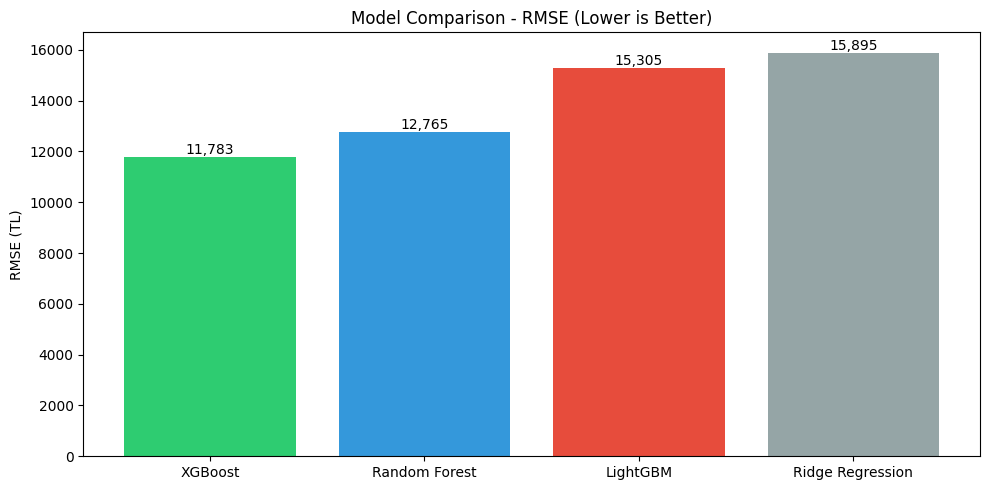

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(results['Model'], results['RMSE'], color=['#2ecc71', '#3498db', '#e74c3c', '#95a5a6'])
ax.set_ylabel('RMSE (TL)')
ax.set_title('Model Comparison - RMSE (Lower is Better)')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis

Analyzing which features have the most impact on price prediction.

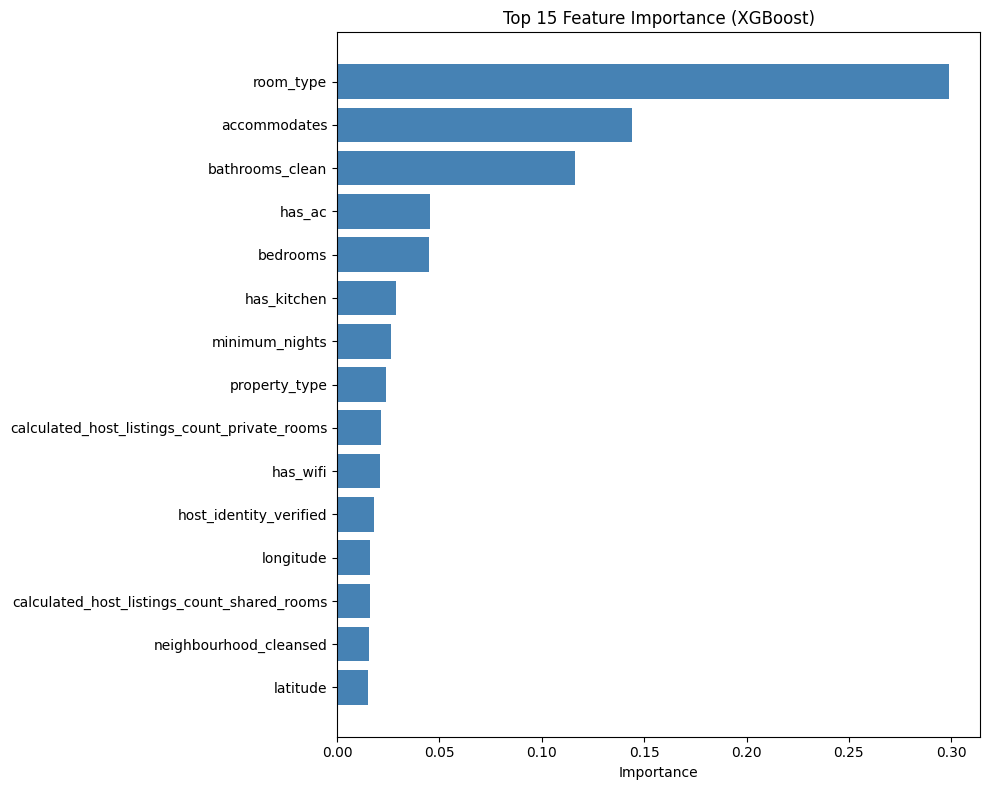


Top 10 Features:
                                     feature  importance
                                   room_type    0.299072
                                accommodates    0.144161
                             bathrooms_clean    0.116421
                                      has_ac    0.045326
                                    bedrooms    0.045042
                                 has_kitchen    0.028887
                              minimum_nights    0.026332
                               property_type    0.023900
calculated_host_listings_count_private_rooms    0.021241
                                    has_wifi    0.020886


In [12]:
# Feature importance from XGBoost
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'].head(15)[::-1], 
         feature_importance['importance'].head(15)[::-1], 
         color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

### SHAP Analysis

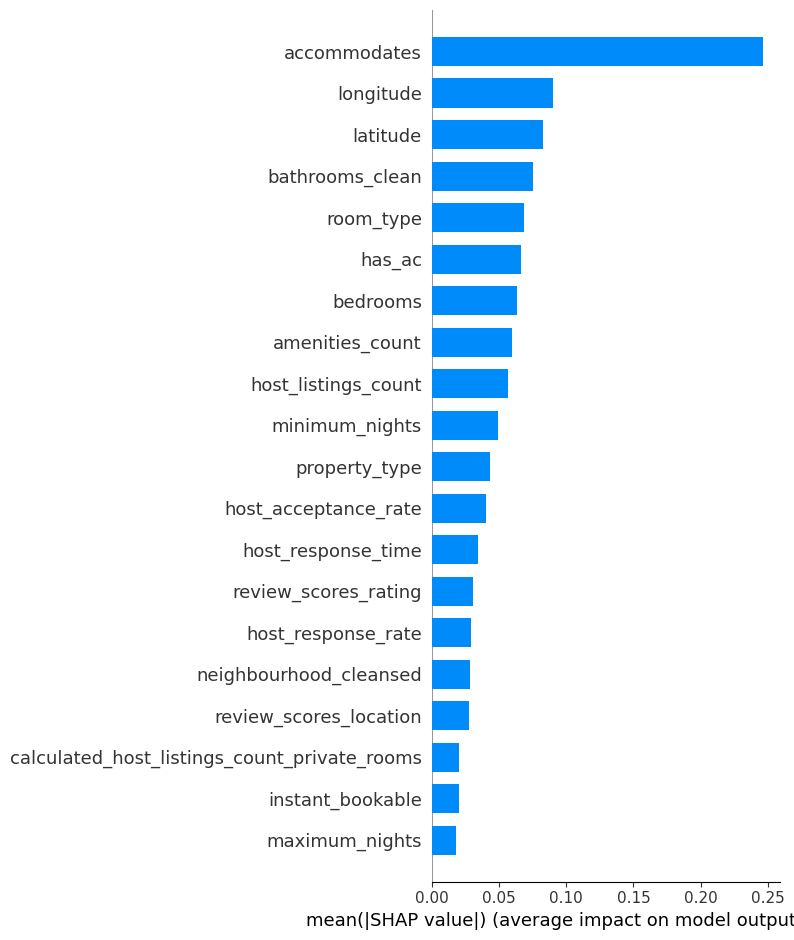

In [13]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, plot_type="bar")

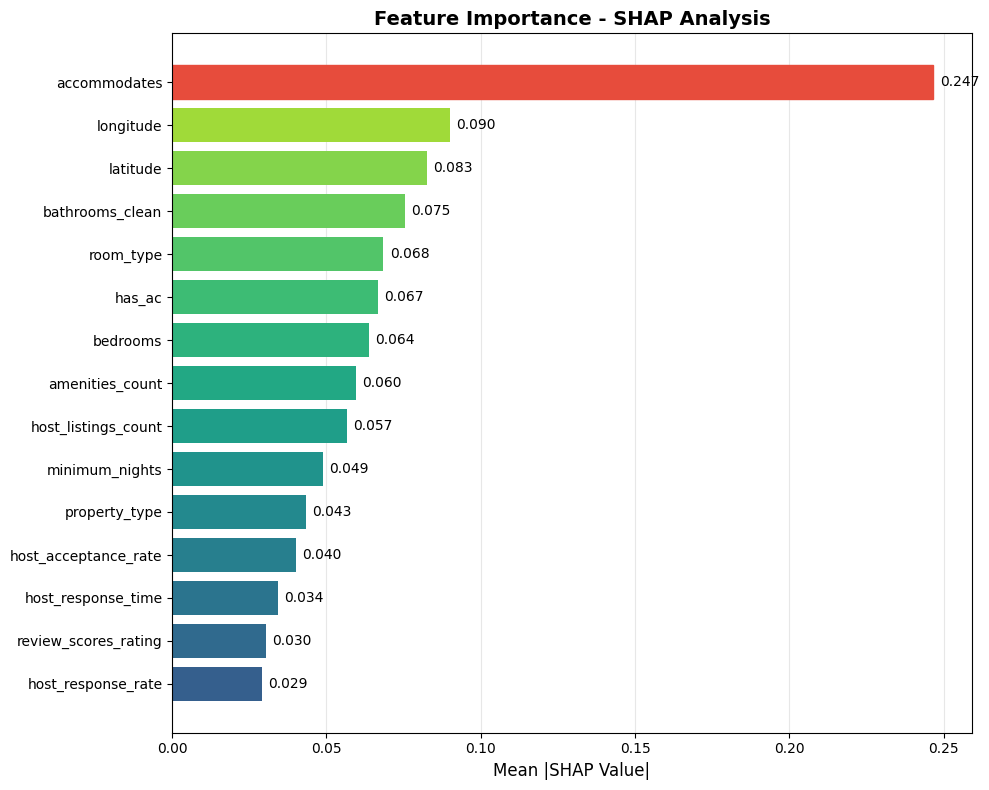

In [33]:
import numpy as np

# SHAP değerlerini hesapla
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_val)

# Feature importance hesapla
feature_importance = np.abs(shap_values).mean(axis=0)
feature_names = X_val.columns

# DataFrame oluştur ve sırala
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=True).tail(15)

# Profesyonel görselleştirme
fig, ax = plt.subplots(figsize=(10, 8))

# Gradient renk
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(shap_df)))

bars = ax.barh(shap_df['Feature'], shap_df['Importance'], color=colors)

# En önemli feature'ı vurgula
bars[-1].set_color('#e74c3c')

ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('Feature Importance - SHAP Analysis', fontsize=14, fontweight='bold')

# Değerleri bar üzerine yaz
for i, (bar, val) in enumerate(zip(bars, shap_df['Importance'])):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=10)

# Grid ekle
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 6. Kaggle Submission

Creating prediction file for Kaggle competition.

In [14]:
# Prepare test data
test_ids = test['id']
X_test = test.drop(columns=['id', 'host_id'], errors='ignore')

print(f"Test features shape: {X_test.shape}")
print(f"Train features shape: {X_train.shape}")

# Check if columns match
missing_cols = set(X_train.columns) - set(X_test.columns)
print(f"\nMissing columns in test: {missing_cols}")

Test features shape: (4750, 28)
Train features shape: (16643, 28)

Missing columns in test: set()


In [15]:
# Prepare test data
test_ids = test['id']
X_test = test.drop(columns=['id', 'host_id'], errors='ignore')

# Predict with XGBoost (best model)
y_test_pred_log = xgb.predict(X_test)

# Convert back from log scale
y_test_pred = np.expm1(y_test_pred_log)

# Create submission file (Kaggle format: ID, TARGET)
submission = pd.DataFrame({
    'ID': test_ids,
    'TARGET': y_test_pred
})

# Save submission
submission.to_csv('../outputs/submission_xgboost.csv', index=False)

print("Submission file created!")
print(f"\nSubmission shape: {submission.shape}")
print(f"\nPredicted price statistics:")
print(submission['TARGET'].describe())

Submission file created!

Submission shape: (4750, 2)

Predicted price statistics:
count     4750.000000
mean      3036.274170
std       2818.826416
min        148.460388
25%       1739.003143
50%       2490.118286
75%       3471.638367
max      61937.921875
Name: TARGET, dtype: float64


## 7. Summary

### Model Results

| Model | RMSE (TL) | MAE (TL) | R² Score |
|-------|-----------|----------|----------|
| XGBoost | 11,783 | 1,746 | 0.458 |
| Random Forest | 12,765 | 1,897 | 0.363 |
| LightGBM | 15,305 | 1,999 | 0.085 |
| Ridge Regression | 15,895 | 2,289 | 0.013 |

### Key Findings

1. **XGBoost performed best** with R² = 0.458 and lowest RMSE
2. **Non-linear models outperform linear models** - Ridge R² = 0.013 vs XGBoost R² = 0.458
3. **Kaggle RMSLE Score:** 0.574

### Top 5 Important Features (SHAP)

1. accommodates
2. longitude
3. latitude
4. bathrooms_clean
5. room_type

### Conclusion

Tree-based models capture non-linear relationships in the data much better than linear regression. Location (lat/long) and property size (accommodates, bathrooms) are the main price drivers.